# Intro

## Global parameters

In [1]:
MAX_TIME_HOURS=1
ALPHA=0.01

## Modules

### Standard

In [2]:
import os, pickle, platform, sys
import numpy as np

In [3]:
from collections import defaultdict

In [4]:
import dcms
from dcms.models import DCMModel, DECMModel, qDECMModel, DWCMModel

In [5]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [6]:
from scipy.stats import spearmanr

In [7]:
from tqdm.notebook import tqdm, trange

In [8]:
import datetime as dt

In [9]:
from bowtie import edges2bowtie

### Home made

In [10]:
if platform.system() == 'Darwin':
    print('Air!')
    HOME = '/Users/fabio/Documents/Lavoro/PythonFiles/bowtie2_py310/bowtie2/'
elif platform.system() == 'Linux':
    print('Stella!')
    HOME = '/home/sarawalk/bowtie2_py39/bowtie2/'
else:
    raise RuntimeError(f"Unsupported OS: {platform.system()}")

sys.path.insert(0, HOME)

Stella!


In [11]:
from auxiliary_functions import el2ks

In [12]:
from sam_bowtie import block_and_fluxes as bnf

## Load data

In [13]:
DATA_FOLDER=HOME+'dati_elezioni/'
TEST_FOLDER=HOME+'tests/'
PVALUE_FOLDER=HOME+'pvalues/'

### Original data

In [14]:
files=os.listdir(DATA_FOLDER)
files.sort()

In [15]:
files

['crisi_dicos.csv',
 'crisi_weighted_edgelist.csv',
 'ita_elections_dicos.csv',
 'ita_elections_weighted_edgelist.csv',
 'quirinale_dicos.csv',
 'quirinale_weighted_edgelist.csv']

In [16]:
l_dataset=len(files)//2

# P-value validation

## FDR function

In [17]:
def fdr(p_vals_list, alpha=0.01):
    p_vals_array = np.array(p_vals_list)
    sorted_indices = np.argsort(p_vals_array)
    sorted_p_vals = p_vals_array[sorted_indices]
    m = len(p_vals_array)
    threshold = np.arange(1, m + 1) * alpha / m
    below_threshold = sorted_p_vals <= threshold
    if not np.any(below_threshold):
        return 0
    max_index = np.max(np.where(below_threshold))
    return threshold[max_index]

## P-value validation

### Fluxes

In [18]:
p_vals_files=os.listdir(PVALUE_FOLDER)
p_vals_files.sort()

In [19]:
fluxes_dict=defaultdict(dict)
for p_val_file in p_vals_files:
    if p_val_file.endswith('fluxes.pkl'):
        with open(PVALUE_FOLDER + '/' + p_val_file, 'rb') as f:
            _p_vals = pickle.load(f)
        p_vals_list=[]
        for key, value in _p_vals.items():
            p_vals_list.append(value['p_value'])
        threshold = fdr(p_vals_list, alpha=ALPHA)
        p_vals_list = np.array(p_vals_list)
        validated_ratio=np.sum(p_vals_list<=threshold)
        key=p_val_file.replace('_pvalues_fluxes.pkl', '')
        fluxes_dict[key]['p_vals'] = _p_vals
        fluxes_dict[key][f'FDR_{ALPHA}'] = threshold
        fluxes_dict[key]['validated_ratio'] = validated_ratio/len(p_vals_list)
        print(f"{key}: validated_ratio={fluxes_dict[key]['validated_ratio']:.3f}")

        

crisi_dico0: validated_ratio=0.980
crisi_dico1: validated_ratio=0.898
crisi_dico2: validated_ratio=0.980
crisi_dico3: validated_ratio=0.867
crisi_dico4: validated_ratio=0.778
ita_elections_dico0: validated_ratio=0.898
ita_elections_dico1: validated_ratio=0.939
ita_elections_dico2: validated_ratio=0.918
ita_elections_dico3: validated_ratio=1.000
ita_elections_dico4: validated_ratio=0.796
ita_elections_dico5: validated_ratio=0.833
ita_elections_dico6: validated_ratio=0.833
quirinale_dico0: validated_ratio=0.918
quirinale_dico1: validated_ratio=0.810
quirinale_dico2: validated_ratio=0.878
quirinale_dico3: validated_ratio=0.800
quirinale_dico4: validated_ratio=0.918
quirinale_dico5: validated_ratio=0.857
quirinale_dico6: validated_ratio=0.776


In [20]:
fluxes_dict_0=defaultdict(dict)
for p_val_file in p_vals_files:
    if p_val_file.endswith('fluxes_0.pkl'):
        with open(PVALUE_FOLDER + '/' + p_val_file, 'rb') as f:
            _p_vals = pickle.load(f)
        p_vals_list=[]
        for key, value in _p_vals.items():
            p_vals_list.append(value['p_value'])
        threshold = fdr(p_vals_list, alpha=ALPHA)
        p_vals_list = np.array(p_vals_list)
        validated_ratio=np.sum(p_vals_list<=threshold)
        key=p_val_file.replace('_pvalues_fluxes_0.pkl', '')
        fluxes_dict_0[key]['p_vals'] = _p_vals
        fluxes_dict_0[key][f'FDR_{ALPHA}'] = threshold
        fluxes_dict_0[key]['validated_ratio'] = validated_ratio/len(p_vals_list)
        print(f"{key}: validated_ratio={fluxes_dict_0[key]['validated_ratio']:.3f}")

        

crisi_dico0: validated_ratio=0.980
crisi_dico1: validated_ratio=0.878
crisi_dico2: validated_ratio=0.980
crisi_dico3: validated_ratio=0.867
crisi_dico4: validated_ratio=0.778
ita_elections_dico0: validated_ratio=0.898
ita_elections_dico1: validated_ratio=0.918
ita_elections_dico2: validated_ratio=0.918
ita_elections_dico3: validated_ratio=1.000
ita_elections_dico4: validated_ratio=0.796
ita_elections_dico5: validated_ratio=0.733
ita_elections_dico6: validated_ratio=0.833
quirinale_dico0: validated_ratio=0.918
quirinale_dico1: validated_ratio=0.810
quirinale_dico2: validated_ratio=0.878
quirinale_dico3: validated_ratio=0.800
quirinale_dico4: validated_ratio=0.918
quirinale_dico5: validated_ratio=0.857
quirinale_dico6: validated_ratio=0.776


#### Differences?

In [21]:
for key in fluxes_dict.keys():
    p_vals=fluxes_dict[key]['p_vals']
    fdr_th=fluxes_dict[key][f'FDR_{ALPHA}']
    fluxes=list(p_vals.keys())
    p_vals=np.array([p_vals[f]['p_value'] for f in fluxes])
    fdr_mask=p_vals<=fdr_th

    p_vals_0=fluxes_dict_0[key]['p_vals']
    fdr_th_0=fluxes_dict_0[key][f'FDR_{ALPHA}']
    p_vals_0=np.array([p_vals_0[f]['p_value'] for f in fluxes])
    fdr_mask_0=p_vals_0<=fdr_th_0

    if np.all(fdr_mask==fdr_mask_0):
        print(f"{key}: FDR masks are the same.")
    else:
        diff_indices = np.where(fdr_mask != fdr_mask_0)[0]

        print(f"{key}: FDR masks differ at:")
        for diff_index in diff_indices:
            print(f"  Index {diff_index}: {fluxes[diff_index]}: p-value={p_vals[diff_index]} vs. {p_vals_0[diff_index]}")

crisi_dico0: FDR masks are the same.
crisi_dico1: FDR masks differ at:
  Index 8: (np.str_('OUTTENDRILS'), np.str_('OUT')): p-value=0.007 vs. 0.0096
crisi_dico2: FDR masks are the same.
crisi_dico3: FDR masks are the same.
crisi_dico4: FDR masks are the same.
ita_elections_dico0: FDR masks are the same.
ita_elections_dico1: FDR masks differ at:
  Index 8: (np.str_('SCC'), np.str_('SCC')): p-value=0.006 vs. 0.0156
ita_elections_dico2: FDR masks are the same.
ita_elections_dico3: FDR masks are the same.
ita_elections_dico4: FDR masks are the same.
ita_elections_dico5: FDR masks differ at:
  Index 2: (np.str_('SCC'), np.str_('SCC')): p-value=0.0 vs. 0.1568
ita_elections_dico6: FDR masks are the same.
quirinale_dico0: FDR masks differ at:
  Index 6: (np.str_('SCC'), np.str_('OUT')): p-value=0.008 vs. 0.0096
  Index 16: (np.str_('OUTTENDRILS'), np.str_('TUBES')): p-value=0.01 vs. 0.0084
quirinale_dico1: FDR masks are the same.
quirinale_dico2: FDR masks are the same.
quirinale_dico3: FDR ma

Among the two, I tend to trust more the one with a greater statistics, i.e. the "0"-version. Nevertheless, the issue is not resolved until I have the counts for the two cases. The only difficult "ones", indeed, are "ita_elections_dico1" and "ita_elections_dico5" as the difference is particularly strong.

#### Validated fluxes and in which direction

In [22]:
for key in fluxes_dict_0.keys():
    p_vals_0=fluxes_dict_0[key]['p_vals']
    fluxes=list(p_vals_0.keys())
    fdr_th_0=fluxes_dict_0[key][f'FDR_{ALPHA}']
    tails_0=np.array([p_vals_0[f]['tail'] for f in fluxes])
    p_vals_0=np.array([p_vals_0[f]['p_value'] for f in fluxes])
    
    fdr_mask_0=p_vals_0<=fdr_th_0

    print(f"\n{key}: FDR mask 0 has {np.sum(fdr_mask_0)} validated fluxes (FDR threshold({ALPHA:.2e})={fdr_th_0:.2e}):")
    for i in range(len(fluxes)):
        if fdr_mask_0[i] and tails_0[i]=='right':
            print(f" {fluxes[i]}: p-value={p_vals_0[i]:.2e}, tail={tails_0[i]}")



crisi_dico0: FDR mask 0 has 48 validated fluxes (FDR threshold(1.00e-02)=9.80e-03):
 ('SCC', 'SCC'): p-value=0.00e+00, tail=right
 ('SCC', 'OUT'): p-value=0.00e+00, tail=right
 ('IN', 'INTENDRILS'): p-value=0.00e+00, tail=right
 ('IN', 'TUBES'): p-value=0.00e+00, tail=right
 ('OUT', 'OUT'): p-value=0.00e+00, tail=right
 ('IN', 'IN'): p-value=0.00e+00, tail=right
 ('OUTTENDRILS', 'OTHERS'): p-value=0.00e+00, tail=right
 ('OUTTENDRILS', 'INTENDRILS'): p-value=0.00e+00, tail=right
 ('OUTTENDRILS', 'OUTTENDRILS'): p-value=0.00e+00, tail=right
 ('INTENDRILS', 'INTENDRILS'): p-value=0.00e+00, tail=right
 ('TUBES', 'INTENDRILS'): p-value=0.00e+00, tail=right
 ('OUTTENDRILS', 'TUBES'): p-value=0.00e+00, tail=right
 ('OTHERS', 'OTHERS'): p-value=0.00e+00, tail=right
 ('TUBES', 'TUBES'): p-value=0.00e+00, tail=right
 ('OTHERS', 'INTENDRILS'): p-value=0.00e+00, tail=right

crisi_dico1: FDR mask 0 has 43 validated fluxes (FDR threshold(1.00e-02)=8.78e-03):
 ('IN', 'OUT'): p-value=0.00e+00, tail=r

### Blocks

In [23]:
block_dict=defaultdict(dict)
for p_val_file in p_vals_files:
    if p_val_file.endswith('blocks.pkl'):
        with open(PVALUE_FOLDER + '/' + p_val_file, 'rb') as f:
            _p_vals = pickle.load(f)
        p_vals_list=[]
        for key, value in _p_vals.items():
            p_vals_list.append(value['p_value'])
        threshold = fdr(p_vals_list, alpha=ALPHA)
        p_vals_list = np.array(p_vals_list)
        validated_ratio=np.sum(p_vals_list<=threshold)
        key=p_val_file.replace('_pvalues_blocks.pkl', '')
        block_dict[key]['p_vals'] = _p_vals
        block_dict[key][f'FDR_{ALPHA}'] = threshold
        block_dict[key]['validated_ratio'] = validated_ratio/len(p_vals_list)
        print(f"{key}: validated_ratio={block_dict[key]['validated_ratio']:.3f}")

crisi_dico0: validated_ratio=1.000
crisi_dico1: validated_ratio=1.000
crisi_dico2: validated_ratio=0.857
crisi_dico3: validated_ratio=0.429
crisi_dico4: validated_ratio=0.571
ita_elections_dico0: validated_ratio=0.857
ita_elections_dico1: validated_ratio=0.714
ita_elections_dico2: validated_ratio=0.857
ita_elections_dico3: validated_ratio=1.000
ita_elections_dico4: validated_ratio=0.429
ita_elections_dico5: validated_ratio=0.714
ita_elections_dico6: validated_ratio=0.429
quirinale_dico0: validated_ratio=0.857
quirinale_dico1: validated_ratio=0.571
quirinale_dico2: validated_ratio=0.714
quirinale_dico3: validated_ratio=0.429
quirinale_dico4: validated_ratio=0.857
quirinale_dico5: validated_ratio=0.286
quirinale_dico6: validated_ratio=0.000


In [24]:
block_dict_0=defaultdict(dict)
for p_val_file in p_vals_files:
    if p_val_file.endswith('blocks_0.pkl'):
        with open(PVALUE_FOLDER + '/' + p_val_file, 'rb') as f:
            _p_vals = pickle.load(f)
        p_vals_list=[]
        for key, value in _p_vals.items():
            p_vals_list.append(value['p_value'])
        threshold = fdr(p_vals_list, alpha=ALPHA)
        p_vals_list = np.array(p_vals_list)
        validated_ratio=np.sum(p_vals_list<=threshold)
        key=p_val_file.replace('_pvalues_blocks_0.pkl', '')
        block_dict_0[key]['p_vals'] = _p_vals
        block_dict_0[key][f'FDR_{ALPHA}'] = threshold
        block_dict_0[key]['validated_ratio'] = validated_ratio/len(p_vals_list)
        print(f"{key}: validated_ratio={block_dict_0[key]['validated_ratio']:.3f}")

        

crisi_dico0: validated_ratio=1.000
crisi_dico1: validated_ratio=1.000
crisi_dico2: validated_ratio=0.857
crisi_dico3: validated_ratio=0.429
crisi_dico4: validated_ratio=0.571
ita_elections_dico0: validated_ratio=0.857
ita_elections_dico1: validated_ratio=0.714
ita_elections_dico2: validated_ratio=0.857
ita_elections_dico3: validated_ratio=1.000
ita_elections_dico4: validated_ratio=0.429
ita_elections_dico5: validated_ratio=0.286
ita_elections_dico6: validated_ratio=0.571
quirinale_dico0: validated_ratio=0.857
quirinale_dico1: validated_ratio=0.571
quirinale_dico2: validated_ratio=0.714
quirinale_dico3: validated_ratio=0.429
quirinale_dico4: validated_ratio=0.857
quirinale_dico5: validated_ratio=0.286
quirinale_dico6: validated_ratio=0.000


#### Differences?

In [25]:
for key in block_dict.keys():
    p_vals=block_dict[key]['p_vals']
    fdr_th=block_dict[key][f'FDR_{ALPHA}']
    blocks=list(p_vals.keys())
    p_vals=np.array([p_vals[f]['p_value'] for f in blocks])
    fdr_mask=p_vals<=fdr_th

    p_vals_0=block_dict_0[key]['p_vals']
    fdr_th_0=block_dict_0[key][f'FDR_{ALPHA}']
    p_vals_0=np.array([p_vals_0[f]['p_value'] for f in blocks])
    fdr_mask_0=p_vals_0<=fdr_th_0

    if np.all(fdr_mask==fdr_mask_0):
        print(f"{key}: FDR masks are the same.")
    else:
        diff_indices = np.where(fdr_mask != fdr_mask_0)[0]

        print(f"{key}: FDR masks differ at:")
        for diff_index in diff_indices:
            print(f"  Index {diff_index}: {blocks[diff_index]}: p-value={p_vals[diff_index]} vs. {p_vals_0[diff_index]}")

crisi_dico0: FDR masks are the same.
crisi_dico1: FDR masks are the same.
crisi_dico2: FDR masks are the same.
crisi_dico3: FDR masks are the same.
crisi_dico4: FDR masks are the same.
ita_elections_dico0: FDR masks are the same.
ita_elections_dico1: FDR masks are the same.
ita_elections_dico2: FDR masks are the same.
ita_elections_dico3: FDR masks are the same.
ita_elections_dico4: FDR masks are the same.
ita_elections_dico5: FDR masks differ at:
  Index 0: OTHERS: p-value=0.0 vs. 0.2464
  Index 4: IN: p-value=0.0 vs. 0.8912
  Index 5: OUTTENDRILS: p-value=0.0 vs. 0.0612
ita_elections_dico6: FDR masks differ at:
  Index 0: OTHERS: p-value=0.293 vs. 0.0
quirinale_dico0: FDR masks are the same.
quirinale_dico1: FDR masks are the same.
quirinale_dico2: FDR masks are the same.
quirinale_dico3: FDR masks are the same.
quirinale_dico4: FDR masks are the same.
quirinale_dico5: FDR masks are the same.
quirinale_dico6: FDR masks are the same.


Again, the differences are minimal and, again, I am trusting more the "0" version, as it has more statistics. 

#### Validated blocks and in which direction

In [26]:
for key in block_dict_0.keys():
    p_vals_0=block_dict_0[key]['p_vals']
    blocks=list(p_vals_0.keys())
    fdr_th_0=block_dict_0[key][f'FDR_{ALPHA}']
    tails_0=np.array([p_vals_0[f]['tail'] for f in blocks])
    p_vals_0=np.array([p_vals_0[f]['p_value'] for f in blocks])
    
    fdr_mask_0=p_vals_0<=fdr_th_0

    print(f"\n{key}: FDR mask 0 has {np.sum(fdr_mask_0)} validated blocks (FDR threshold({ALPHA:.2e})={fdr_th_0:.2e}):")
    for i in range(len(blocks)):
        if fdr_mask_0[i]:
            print(f" {blocks[i]}: p-value={p_vals_0[i]:.2e}, tail={tails_0[i]}")



crisi_dico0: FDR mask 0 has 7 validated blocks (FDR threshold(1.00e-02)=1.00e-02):
 OUT: p-value=8.00e-04, tail=left
 INTENDRILS: p-value=0.00e+00, tail=right
 SCC: p-value=3.20e-03, tail=right
 OUTTENDRILS: p-value=0.00e+00, tail=right
 OTHERS: p-value=0.00e+00, tail=right
 IN: p-value=0.00e+00, tail=left
 TUBES: p-value=0.00e+00, tail=right

crisi_dico1: FDR mask 0 has 7 validated blocks (FDR threshold(1.00e-02)=1.00e-02):
 OUT: p-value=0.00e+00, tail=left
 INTENDRILS: p-value=0.00e+00, tail=right
 SCC: p-value=0.00e+00, tail=right
 IN: p-value=0.00e+00, tail=right
 OUTTENDRILS: p-value=0.00e+00, tail=right
 OTHERS: p-value=0.00e+00, tail=right
 TUBES: p-value=0.00e+00, tail=right

crisi_dico2: FDR mask 0 has 6 validated blocks (FDR threshold(1.00e-02)=8.57e-03):
 INTENDRILS: p-value=0.00e+00, tail=right
 OUT: p-value=2.40e-03, tail=left
 OTHERS: p-value=0.00e+00, tail=right
 OUTTENDRILS: p-value=0.00e+00, tail=right
 SCC: p-value=0.00e+00, tail=right
 TUBES: p-value=0.00e+00, tail=

## Plots

In [27]:
from plot_bowtie import plot_bowtie

Plotting: crisi_dico0


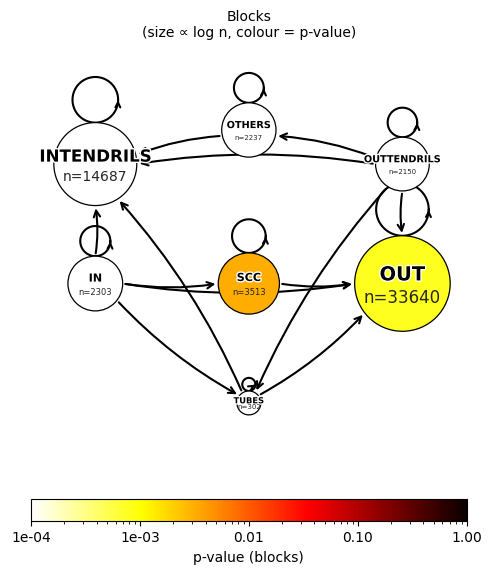

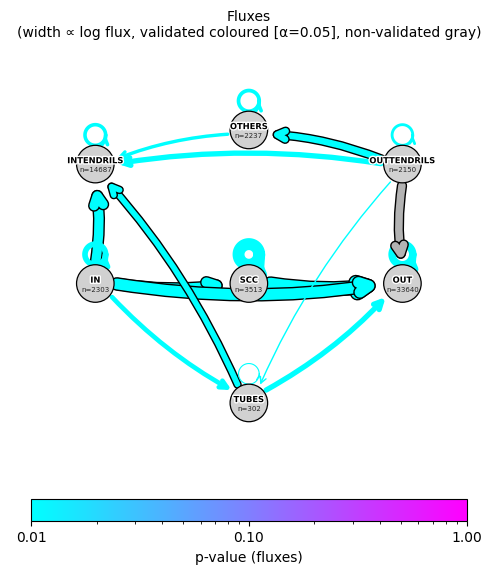

In [28]:
# Pick any dataset to visualise — change the key as needed
dataset = list(block_dict_0.keys())[0]
print(f"Plotting: {dataset}")

bow_tie_figs = plot_bowtie(
    block_dict=block_dict_0[dataset]['p_vals'],
    flux_dict =fluxes_dict_0[dataset]['p_vals'],
)
for bow_tie_fig in bow_tie_figs:
    #plt.savefig(TEST_FOLDER + f"/{dataset}_bowtie_plot.png", dpi=300)
    plt.show()
